# Introduction to Unsupervised Learning

Unsupervised Learning is a type of machine learning in which the model is trained on data without target labels.

In supervised learning, we already know the correct answer.  
But in unsupervised learning, the machine does not know the output.  
It studies the data and tries to find hidden patterns, groups, or structure by itself.

## Simple Meaning
The machine learns from data without teacher or answer key.

## Example
Suppose we have customer data but no labels like "rich", "middle", or "budget".  
The machine can group customers based on similar behavior. This is unsupervised learning.

# Why Use Unsupervised Learning?

Unsupervised learning is used when labeled data is not available.

It helps to:
1. Find hidden patterns in data
2. Group similar items
3. Detect unusual data points
4. Reduce the number of features
5. Make data easier to understand

## Main Goal
To discover useful structure from raw data.

# Types of Unsupervised Learning

There are mainly two important types:

## 1. Clustering
Clustering means grouping similar data points together.

### Examples
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN

## 2. Dimensionality Reduction
Dimensionality reduction means reducing the number of input features while keeping important information.

### Example
- PCA (Principal Component Analysis)

# Supervised Learning vs Unsupervised Learning

| Feature | Supervised Learning | Unsupervised Learning |
|---------|---------------------|-----------------------|
| Labels | Present | Not Present |
| Output | Known | Unknown |
| Goal | Predict output | Find patterns |
| Example | Classification, Regression | Clustering, PCA |
| Teacher | Available | Not available |

## In Simple Words
- Supervised learning = learning with answers
- Unsupervised learning = learning without answers

# Important Unsupervised Algorithms

In this notebook, we will study:

## 1. K-Means Clustering
Groups data into K clusters using centroids.

## 2. Hierarchical Clustering
Builds clusters step by step in a tree-like structure.

## 3. DBSCAN
Forms clusters based on density and also finds noise points.

## 4. PCA
Reduces the number of features and helps in visualization.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Explanation of Imported Libraries

We imported the following libraries:

- `numpy` → used for numerical calculations
- `pandas` → used for working with data in table form
- `matplotlib.pyplot` → used for plotting graphs
- `make_blobs` → used to create sample clustered dataset
- `KMeans` → used for K-Means clustering
- `DBSCAN` → used for density-based clustering
- `PCA` → used for dimensionality reduction
- `StandardScaler` → used to scale data
- `dendrogram` and `linkage` → used for hierarchical clustering

These libraries help us perform unsupervised learning practically.

# Dataset Creation

To understand unsupervised learning clearly, we will first create a sample dataset.

We use `make_blobs()` because it creates groups of points which are useful for clustering.

## Meaning of Parameters
- `n_samples=300` → creates 300 data points
- `centers=4` → data will be around 4 cluster centers
- `cluster_std=1.0` → spread of the points
- `random_state=42` → gives same output every time

In [2]:
# Create sample dataset

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

print("Shape of dataset:", X.shape)
print("First 5 data points:\n", X[:5])

Shape of dataset: (300, 2)
First 5 data points:
 [[ -9.29768866   6.47367855]
 [ -9.69874112   6.93896737]
 [ -1.68665271   7.79344248]
 [ -7.09730839  -5.78133274]
 [-10.87645229   6.3154366 ]]


In [3]:
# Convert into DataFrame for better understanding

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df.head()

,Feature_1,Feature_2
0,-9.297689,6.473679
1,-9.698741,6.938967
2,-1.686653,7.793442
3,-7.097308,-5.781333
4,-10.876452,6.315437


# Program Explanation: Dataset Creation

In this program, we created an artificial dataset using `make_blobs()`.

## Why?
Because clustering algorithms need data points to group.

## What Happened?
- 300 points were created
- They are distributed around 4 centers
- Each point has 2 features

This dataset is useful because it is simple and easy to visualize.

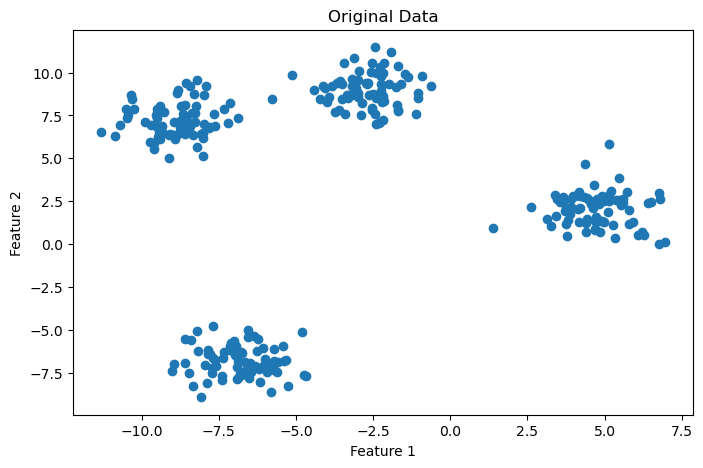

In [4]:
# Visualize original data

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Program Explanation: Data Visualization

We used `plt.scatter()` to display the dataset.

## Meaning of the Graph
- Each dot represents one data point
- Nearby dots may belong to the same group
- Since no clustering is applied yet, all points are shown in one color

This graph gives us a visual idea of the data before applying any algorithm.

# K-Means Clustering

K-Means is one of the most popular clustering algorithms.

It divides data into K groups, where K is chosen by the user.

## Working of K-Means
1. Select number of clusters K
2. Choose random centroids
3. Assign each point to the nearest centroid
4. Recalculate centroid positions
5. Repeat until clusters become stable

## Goal
To minimize the distance between points and their cluster centroids.

# Formula Used in K-Means

K-Means generally uses Euclidean Distance to measure closeness.

## Euclidean Distance Formula

Distance = √((x2 - x1)^2 + (y2 - y1)^2)

The point is assigned to the nearest centroid based on this distance.

## Centroid
Centroid is the average position of all points in a cluster.

In [5]:
# Apply K-Means clustering

kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

print("Cluster labels assigned by K-Means:")
print(y_kmeans[:20])

Cluster labels assigned by K-Means:
[3 3 0 1 3 1 2 1 0 2 0 2 0 0 3 0 3 2 0 0]


c:\Users\saksh\anaconda3_new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


# Program Explanation: K-Means Program

In this code:

- `KMeans(n_clusters=4, random_state=42)` creates a K-Means model with 4 clusters
- `fit_predict(X)` does two jobs:
  1. fits the model on data
  2. predicts the cluster label for each point

## Output
Each point gets a cluster label such as:
- 0
- 1
- 2
- 3

These labels represent the group of each data point.

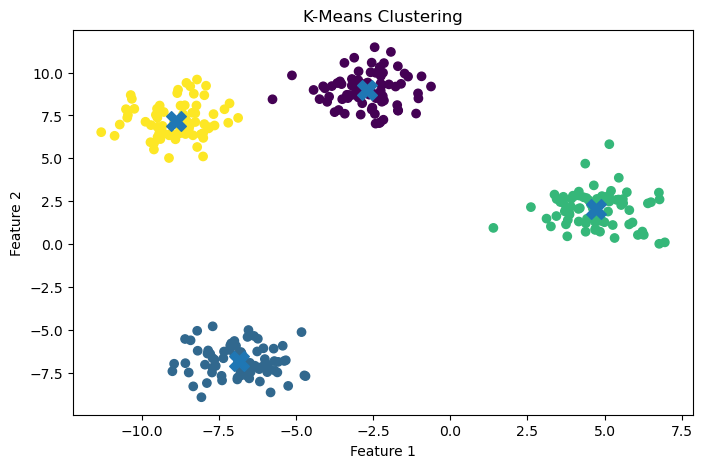

In [6]:
# Visualize K-Means clustering result

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Program Explanation: K-Means Graph

In this graph:

- `c=y_kmeans` colors the data points based on cluster labels
- `kmeans.cluster_centers_` gives the centroid positions
- Marker `X` shows the centroids

## Meaning
- Same color points belong to the same cluster
- X marks show the center of each cluster

This graph clearly shows how K-Means grouped the data.

# Elbow Method

The Elbow Method helps us choose the best value of K.

It uses the concept of inertia.

## Inertia
Inertia is the sum of squared distances of points from their nearest centroid.

If K increases, inertia decreases.  
But after some point, improvement becomes very small.  
That turning point is called the elbow point.

That elbow point is considered the best K.

c:\Users\saksh\anaconda3_new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\saksh\anaconda3_new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\saksh\anaconda3_new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\saksh\anaconda3_new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

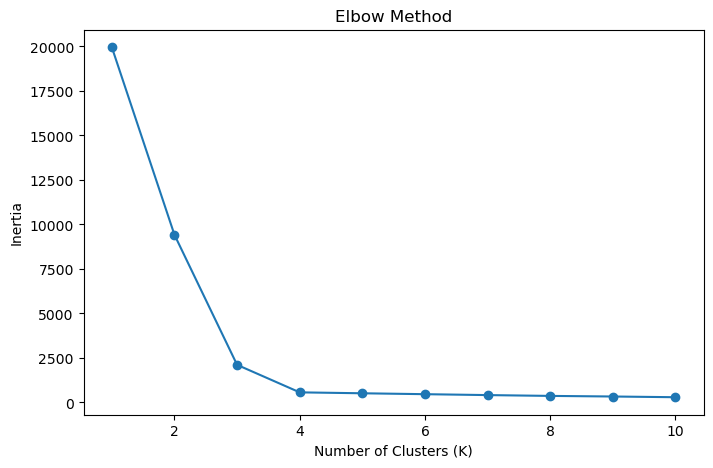

In [7]:
# Elbow Method

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Program Explanation: Elbow Method

In this code:

- We run K-Means for K = 1 to 10
- For each K, we store inertia
- Then we plot K vs inertia

## Meaning of the Graph
- Inertia decreases as K increases
- The curve bends at one point
- That bend is called the elbow

The elbow point gives the most suitable number of clusters.

# Hierarchical Clustering

Hierarchical clustering builds clusters step by step.

## Types
1. Agglomerative Clustering
   - Starts with each point as separate cluster
   - Merges nearby clusters step by step

2. Divisive Clustering
   - Starts with one big cluster
   - Divides into smaller clusters

Most commonly used: Agglomerative Clustering

# Dendrogram

A dendrogram is a tree-like diagram used in hierarchical clustering.

It shows:
- which points or clusters are merged
- at what distance they are merged

By cutting the dendrogram at a certain height, we can decide the number of clusters.

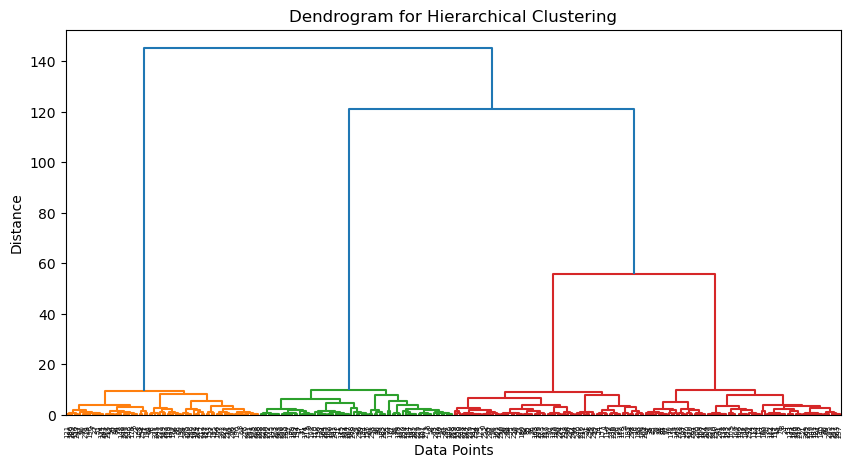

In [8]:
# Create linkage matrix for hierarchical clustering

linked = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# Program Explanation: Hierarchical Clustering

In this program:

- `linkage(X, method='ward')` calculates how clusters should be merged
- `dendrogram(linked)` draws the tree-like structure

## Meaning
- Lower merges mean points are very close
- Higher merges mean points/clusters are farther apart

By observing the biggest vertical gap, we can estimate a good number of clusters.

# DBSCAN

DBSCAN stands for Density-Based Spatial Clustering of Applications with Noise.

It is a clustering algorithm based on density.

## Main Idea
- Dense areas form clusters
- Sparse areas may be treated as noise

## Important Terms
1. Core Point
2. Border Point
3. Noise Point

# Parameters of DBSCAN

## 1. eps
The maximum distance between two points for them to be considered neighbors.

## 2. min_samples
Minimum number of points required to form a dense region.

## Advantage
DBSCAN can find clusters of irregular shape and can also detect outliers.

In [9]:
# Apply DBSCAN clustering

dbscan = DBSCAN(eps=0.8, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

print("DBSCAN labels:")
print(y_dbscan[:20])

DBSCAN labels:
[ 0  0  1  2  0  2  3  2  1  3  1  3  1  1  0  1  0 -1  1  1]


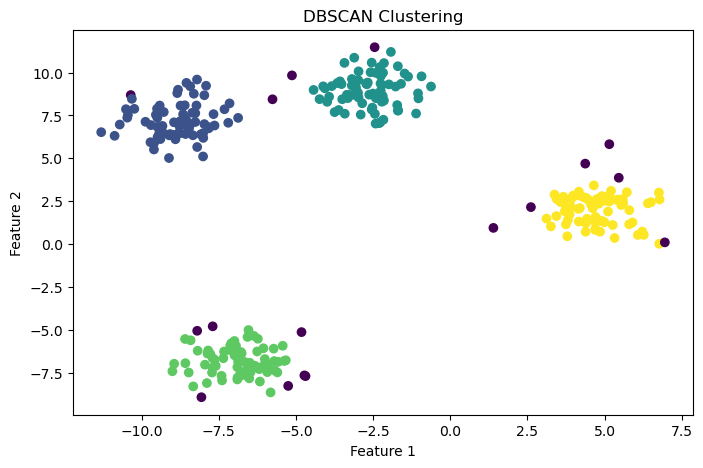

In [10]:
# Visualize DBSCAN result

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Program Explanation: DBSCAN

In this code:

- `DBSCAN(eps=0.8, min_samples=5)` creates the DBSCAN model
- `fit_predict(X)` assigns a label to each point

## Important Note
If a point is treated as noise, DBSCAN gives it label `-1`.

## Meaning of Graph
- Same color points form one cluster
- Noise points may appear with separate color

DBSCAN is very useful when data has irregular shape or outliers.

# PCA (Principal Component Analysis)

PCA is a dimensionality reduction technique.

It reduces the number of features while keeping maximum important information.

## Why Use PCA?
- Makes data simpler
- Reduces computation time
- Helps in visualization
- Removes redundancy

# Main Idea of PCA

PCA creates new features called principal components.

These components:
- are combinations of original features
- capture maximum variance in the data

## Simple Meaning
PCA rotates and compresses the data in a better direction so that most information is preserved.

In [11]:
# Standardize data before PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First 5 scaled rows:\n", X_scaled[:5])

First 5 scaled rows:
 [[-1.11618972  0.58377179]
 [-1.19214185  0.65863295]
 [ 0.32520384  0.79611099]
 [-0.6994772  -1.38795911]
 [-1.4151792   0.55831196]]


# Why Standardization is Needed Before PCA

PCA depends on variance.

If one feature has very large values and another has small values, the large feature may dominate.

So we standardize the data using `StandardScaler()`.

## Result
- Mean becomes nearly 0
- Standard deviation becomes nearly 1

In [12]:
# Apply PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Shape after PCA: (300, 2)
Explained variance ratio: [0.52896325 0.47103675]


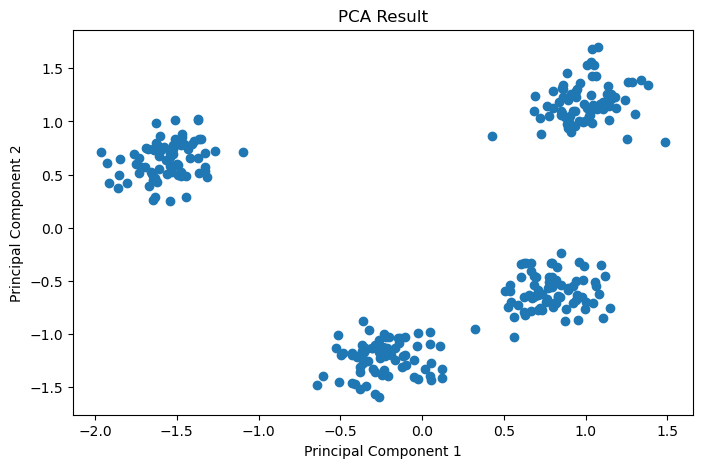

In [13]:
# Visualize PCA result

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Result")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Program Explanation: PCA

In this code:

- `PCA(n_components=2)` reduces the data to 2 principal components
- `fit_transform(X_scaled)` learns the important directions and transforms the data

## Explained Variance Ratio
It tells how much information is captured by each principal component.

## Meaning of Graph
The graph shows the data in reduced form using principal components instead of original features.

# Comparison of Algorithms

| Algorithm | Category | Main Idea | Advantage | Disadvantage |
|-----------|----------|-----------|------------|--------------|
| K-Means | Clustering | Uses centroids | Simple and fast | Need to choose K |
| Hierarchical | Clustering | Builds tree of clusters | Easy to visualize | Slow for large data |
| DBSCAN | Clustering | Uses density | Detects noise and irregular clusters | Sensitive to parameters |
| PCA | Dimensionality Reduction | Reduces features | Fast and useful for visualization | Some information may be lost |

# Advantages of Unsupervised Learning

1. Works without labeled data
2. Finds hidden patterns in data
3. Useful for grouping similar data
4. Helps reduce data complexity
5. Useful in customer segmentation and anomaly detection

# Disadvantages of Unsupervised Learning

1. Output may be difficult to interpret
2. No correct answer is given, so evaluation is harder
3. Sensitive to parameter choice
4. Some algorithms are slow on large datasets
5. Results may vary depending on data quality

# Applications of Unsupervised Learning

Unsupervised learning is used in many real-life applications such as:

- Customer segmentation
- Market basket analysis
- Recommendation systems
- Fraud detection
- Image compression
- Document grouping
- Social network analysis
- Anomaly detection

# How to Understand the Full Program

This notebook follows a simple order:

1. Import libraries  
2. Create dataset  
3. Visualize data  
4. Apply clustering algorithm  
5. Show output graph  
6. Understand result  
7. Apply dimensionality reduction  
8. Compare all methods  

If you remember this flow, the program becomes very easy to understand.

# Quick Formula Notes

## Euclidean Distance
Distance = √((x2 - x1)^2 + (y2 - y1)^2)

Used in K-Means to assign points to nearest centroid.

## Inertia
Sum of squared distances of data points from their nearest centroid.

Used in Elbow Method.

## Principal Components
New axes that capture maximum variance in the data.

Used in PCA.

# Short Revision Notes

## Unsupervised Learning
Learning from data without labels.

## Clustering
Grouping similar data points.

## K-Means
Groups data using K centroids.

## Elbow Method
Used to choose best K.

## Hierarchical Clustering
Builds clusters in tree form.

## Dendrogram
Shows how clusters merge.

## DBSCAN
Density-based clustering that also finds noise.

## PCA
Reduces number of features while preserving important information.